A model for recognizing original and fake products from popular fashion brands

In [1]:
# 1. INSTALL

!pip install torch torchvision pillow scikit-learn -q

In [2]:
# 2. IMPORT

import os
import json
import zipfile
import random
from collections import defaultdict, Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

In [3]:
# 3. SEED

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [4]:
# 4. UNZIP

zip_path = "/content/Fake Brand Dataset.zip"
extract_path = "/content/fashion_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unpacking is complete.")

Unpacking is complete.


In [5]:
# 5. ROOT_DIR SEARCH

def find_dataset_root(base_path):
    items = os.listdir(base_path)

    if "train" in items or "test" in items:
        return base_path

    for item in items:
        candidate = os.path.join(base_path, item)
        if os.path.isdir(candidate):
            subitems = os.listdir(candidate)
            if "train" in subitems or "test" in subitems:
                return candidate

    raise ValueError("Couldn't find the folder with train/test")

root_dir = find_dataset_root(extract_path)
print("root_dir =", root_dir)
print("Содержимое root_dir:", os.listdir(root_dir))

root_dir = /content/fashion_data
Содержимое root_dir: ['train']


In [6]:
# 6. COLLECTING PATHS

def collect_samples(root_dir):
    samples = {"train": [], "test": []}

    for split in ["train", "test"]:
        split_path = os.path.join(root_dir, split)

        if not os.path.exists(split_path):
            continue

        for label in os.listdir(split_path):
            class_path = os.path.join(split_path, label)

            if not os.path.isdir(class_path):
                continue

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(class_path, img_name)
                    samples[split].append((img_path, label))

    return samples

all_samples = collect_samples(root_dir)

print("Train raw:", len(all_samples["train"]))
print("Test raw:", len(all_samples["test"]))

Train raw: 1565
Test raw: 0


In [7]:
# 7. BINARY LABEL

def to_binary_label(label):
    label = label.lower()
    return "fake" if "fake" in label else "genuine"

In [8]:
# 8. STRATIFIED LIMIT

def stratified_limit_binary(samples, max_total=500, seed=42):
    random.seed(seed)

    if len(samples) == 0:
        raise ValueError("An empty list of samples")

    by_class = defaultdict(list)

    for img_path, original_label in samples:
        binary_label = to_binary_label(original_label)
        by_class[binary_label].append((img_path, binary_label))

    if len(by_class) == 0:
        raise ValueError("Classes not found")

    class_names = list(by_class.keys())
    per_class = max_total // len(class_names)

    selected = []
    leftovers = []

    for cls in class_names:
        cls_items = by_class[cls]
        random.shuffle(cls_items)

        take = min(len(cls_items), per_class)
        selected.extend(cls_items[:take])
        leftovers.extend(cls_items[take:])

    remaining = max_total - len(selected)
    if remaining > 0:
        random.shuffle(leftovers)
        selected.extend(leftovers[:remaining])

    random.shuffle(selected)
    return selected[:max_total]

In [9]:
# 9. LIMIT 500

if len(all_samples["train"]) == 0:
    raise ValueError("Train is empty")

if len(all_samples["test"]) == 0:
    print("⚠️ test not found, making a split from train")

    limited_all = stratified_limit_binary(all_samples["train"], max_total=500, seed=42)

    by_class = defaultdict(list)
    for item in limited_all:
        by_class[item[1]].append(item)

    train_samples = []
    test_samples = []

    for cls, items in by_class.items():
        random.shuffle(items)
        split_idx = int(0.8 * len(items))
        train_samples.extend(items[:split_idx])
        test_samples.extend(items[split_idx:])
else:
    train_samples = stratified_limit_binary(all_samples["train"], max_total=400, seed=42)
    test_samples = stratified_limit_binary(all_samples["test"], max_total=100, seed=42)

print("Train final:", len(train_samples))
print("Test final:", len(test_samples))
print("Train distribution:", Counter([y for _, y in train_samples]))
print("Test distribution:", Counter([y for _, y in test_samples]))

⚠️ test not found, making a split from train
Train final: 400
Test final: 100
Train distribution: Counter({'genuine': 200, 'fake': 200})
Test distribution: Counter({'genuine': 50, 'fake': 50})


In [10]:
# 10. LABEL MAP

class_to_idx = {"genuine": 0, "fake": 1}
idx_to_class = {0: "genuine", 1: "fake"}
num_classes = 2

In [11]:
# 11. TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

tta_transform_hflip = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
# 12. DATASET

class FashionBinaryDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        y = self.class_to_idx[label]

        if self.transform:
            image = self.transform(image)

        return image, y

In [13]:
# 13. DATALOADERS

batch_size = 16

train_dataset = FashionBinaryDataset(train_samples, class_to_idx, transform=train_transform)
test_dataset = FashionBinaryDataset(test_samples, class_to_idx, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 25
Test batches: 7


In [14]:
# 14. DEVICE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [15]:
# 15. CLASS WEIGHTS

train_labels_idx = [class_to_idx[label] for _, label in train_samples]
counts = Counter(train_labels_idx)

class_weights = []
for i in range(num_classes):
    class_weights.append(len(train_labels_idx) / counts[i])

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Class weights: tensor([2., 2.])


In [16]:
# 16. MODEL: EfficientNet-B0

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)
print("Model ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 44.5MB/s]


Model ready.


In [17]:
# 17. LOSS / OPTIMIZER / SCHEDULER

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

In [18]:
# 18. TRAIN / EVAL UTILS

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


def predict_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # probability(fake)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_probs)


def evaluate_with_threshold(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]

            running_loss += loss.item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, all_preds)
    return running_loss / len(loader), acc, all_labels, all_preds, all_probs

In [19]:
# 19. FINDING THE BEST THRESHOLD

def find_best_threshold(y_true, y_prob):
    best_thr = 0.5
    best_f1 = -1

    for thr in np.arange(0.30, 0.71, 0.02):
        y_pred = (y_prob >= thr).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1

In [20]:
# 20. EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop

In [21]:
# 21. STAGE 1: TRAIN HEAD

best_model_path = "/content/best_prod_model.pth"
best_config_path = "/content/model_config.json"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "best_threshold": []
}

best_acc = 0.0
best_threshold = 0.5
early_stopping = EarlyStopping(patience=4, min_delta=0.001)

epochs_stage1 = 12

for epoch in range(epochs_stage1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    y_true_prob, y_prob = predict_probs(model, test_loader, device)
    current_threshold, best_f1 = find_best_threshold(y_true_prob, y_prob)

    val_loss, val_acc, y_true, y_pred, y_prob = evaluate_with_threshold(
        model, test_loader, criterion, device, threshold=current_threshold
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["best_threshold"].append(current_threshold)

    print(f"Epoch {epoch+1}/{epochs_stage1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Thr: {current_threshold:.2f}")
    print("-" * 60)

    if val_acc > best_acc:
        best_acc = val_acc
        best_threshold = current_threshold
        torch.save(model.state_dict(), best_model_path)

        config = {
            "class_to_idx": class_to_idx,
            "idx_to_class": idx_to_class,
            "threshold": best_threshold,
            "model_name": "efficientnet_b0_binary"
        }

        with open(best_config_path, "w") as f:
            json.dump(config, f)

    if early_stopping.step(val_acc):
        print("Early stopping on stage 1")
        break

print("Best stage1 acc:", best_acc)
print("Best stage1 threshold:", best_threshold)

Epoch 1/12
Train Loss: 0.6762 | Train Acc: 0.5650
Val   Loss: 0.6414 | Val   Acc: 0.6500 | Thr: 0.32
------------------------------------------------------------
Epoch 2/12
Train Loss: 0.5769 | Train Acc: 0.7175
Val   Loss: 0.5449 | Val   Acc: 0.7400 | Thr: 0.34
------------------------------------------------------------
Epoch 3/12
Train Loss: 0.5402 | Train Acc: 0.7250
Val   Loss: 0.5288 | Val   Acc: 0.7300 | Thr: 0.32
------------------------------------------------------------
Epoch 4/12
Train Loss: 0.4819 | Train Acc: 0.7975
Val   Loss: 0.5052 | Val   Acc: 0.7100 | Thr: 0.30
------------------------------------------------------------
Epoch 5/12
Train Loss: 0.4838 | Train Acc: 0.7875
Val   Loss: 0.5350 | Val   Acc: 0.7200 | Thr: 0.30
------------------------------------------------------------
Epoch 6/12
Train Loss: 0.5082 | Train Acc: 0.7600
Val   Loss: 0.5080 | Val   Acc: 0.7700 | Thr: 0.54
------------------------------------------------------------
Epoch 7/12
Train Loss: 0.466

In [22]:
# 22. STAGE 2: FINE-TUNING

for name, param in model.named_parameters():
    if "features.6" in name or "features.7" in name or "features.8" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    patience=2,
    factor=0.5
)

early_stopping = EarlyStopping(patience=4, min_delta=0.001)

epochs_stage2 = 8

for epoch in range(epochs_stage2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    y_true_prob, y_prob = predict_probs(model, test_loader, device)
    current_threshold, best_f1 = find_best_threshold(y_true_prob, y_prob)

    val_loss, val_acc, y_true, y_pred, y_prob = evaluate_with_threshold(
        model, test_loader, criterion, device, threshold=current_threshold
    )

    scheduler.step(val_acc)

    print(f"Fine-tune Epoch {epoch+1}/{epochs_stage2}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Thr: {current_threshold:.2f}")
    print("-" * 60)

    if val_acc > best_acc:
        best_acc = val_acc
        best_threshold = current_threshold
        torch.save(model.state_dict(), best_model_path)

        config = {
            "class_to_idx": class_to_idx,
            "idx_to_class": idx_to_class,
            "threshold": best_threshold,
            "model_name": "efficientnet_b0_binary"
        }

        with open(best_config_path, "w") as f:
            json.dump(config, f)

    if early_stopping.step(val_acc):
        print("Early stopping on stage 2")
        break

print("Best overall acc:", best_acc)
print("Best overall threshold:", best_threshold)

Fine-tune Epoch 1/8
Train Loss: 0.4389 | Train Acc: 0.7850
Val   Loss: 0.5160 | Val   Acc: 0.7700 | Thr: 0.36
------------------------------------------------------------
Fine-tune Epoch 2/8
Train Loss: 0.3797 | Train Acc: 0.8250
Val   Loss: 0.5146 | Val   Acc: 0.7500 | Thr: 0.38
------------------------------------------------------------
Fine-tune Epoch 3/8
Train Loss: 0.3094 | Train Acc: 0.8675
Val   Loss: 0.4969 | Val   Acc: 0.7900 | Thr: 0.58
------------------------------------------------------------
Fine-tune Epoch 4/8
Train Loss: 0.2916 | Train Acc: 0.8875
Val   Loss: 0.5042 | Val   Acc: 0.7400 | Thr: 0.34
------------------------------------------------------------
Fine-tune Epoch 5/8
Train Loss: 0.2166 | Train Acc: 0.9325
Val   Loss: 0.5100 | Val   Acc: 0.7900 | Thr: 0.64
------------------------------------------------------------
Fine-tune Epoch 6/8
Train Loss: 0.1736 | Train Acc: 0.9350
Val   Loss: 0.5469 | Val   Acc: 0.7300 | Thr: 0.36
-----------------------------------

In [23]:
# 23. LOAD BEST MODEL

with open(best_config_path, "r") as f:
    saved_config = json.load(f)

best_threshold = saved_config["threshold"]

model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.35),
    nn.Linear(in_features, 2)
)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)
model.eval()

print("Best model loaded.")
print("Threshold:", best_threshold)

Best model loaded.
Threshold: 0.5800000000000003


In [24]:
# 24. FINAL EVAL

test_loss, test_acc, y_true, y_pred, y_prob = evaluate_with_threshold(
    model, test_loader, criterion, device, threshold=best_threshold
)

print("Final Test Accuracy:", test_acc)
print("Threshold used:", best_threshold)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["genuine", "fake"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Final Test Accuracy: 0.79
Threshold used: 0.5800000000000003

Classification Report:

              precision    recall  f1-score   support

     genuine       0.76      0.84      0.80        50
        fake       0.82      0.74      0.78        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100

Confusion Matrix:
[[42  8]
 [13 37]]


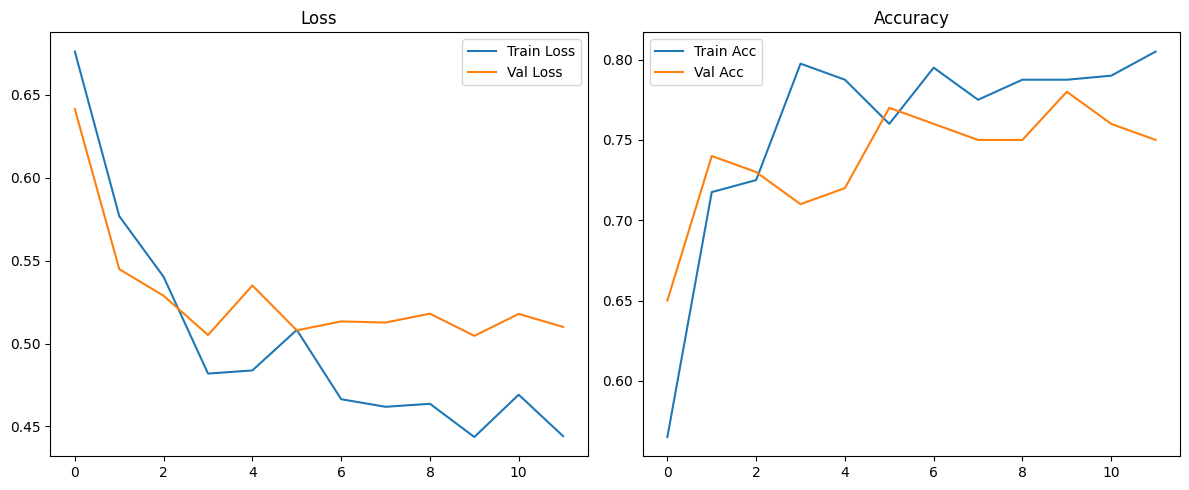

In [25]:
# 25. PLOTS

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# 26. TTA INFERENCE FOR SINGLE IMAGE

def load_image_for_tta(image_path):
    img = Image.open(image_path).convert("RGB")
    x1 = test_transform(img).unsqueeze(0)
    x2 = tta_transform_hflip(img).unsqueeze(0)
    return x1, x2, img


def predict_image_tta(model, image_path, threshold=0.5, device="cpu"):
    x1, x2, original_img = load_image_for_tta(image_path)

    x1 = x1.to(device)
    x2 = x2.to(device)

    with torch.no_grad():
        p1 = torch.softmax(model(x1), dim=1)[:, 1]
        p2 = torch.softmax(model(x2), dim=1)[:, 1]

    prob_fake = ((p1 + p2) / 2.0).item()
    pred = 1 if prob_fake >= threshold else 0
    label = idx_to_class[pred]

    return {
        "label": label,
        "prob_fake": prob_fake,
        "prob_genuine": 1 - prob_fake,
        "image": original_img
    }

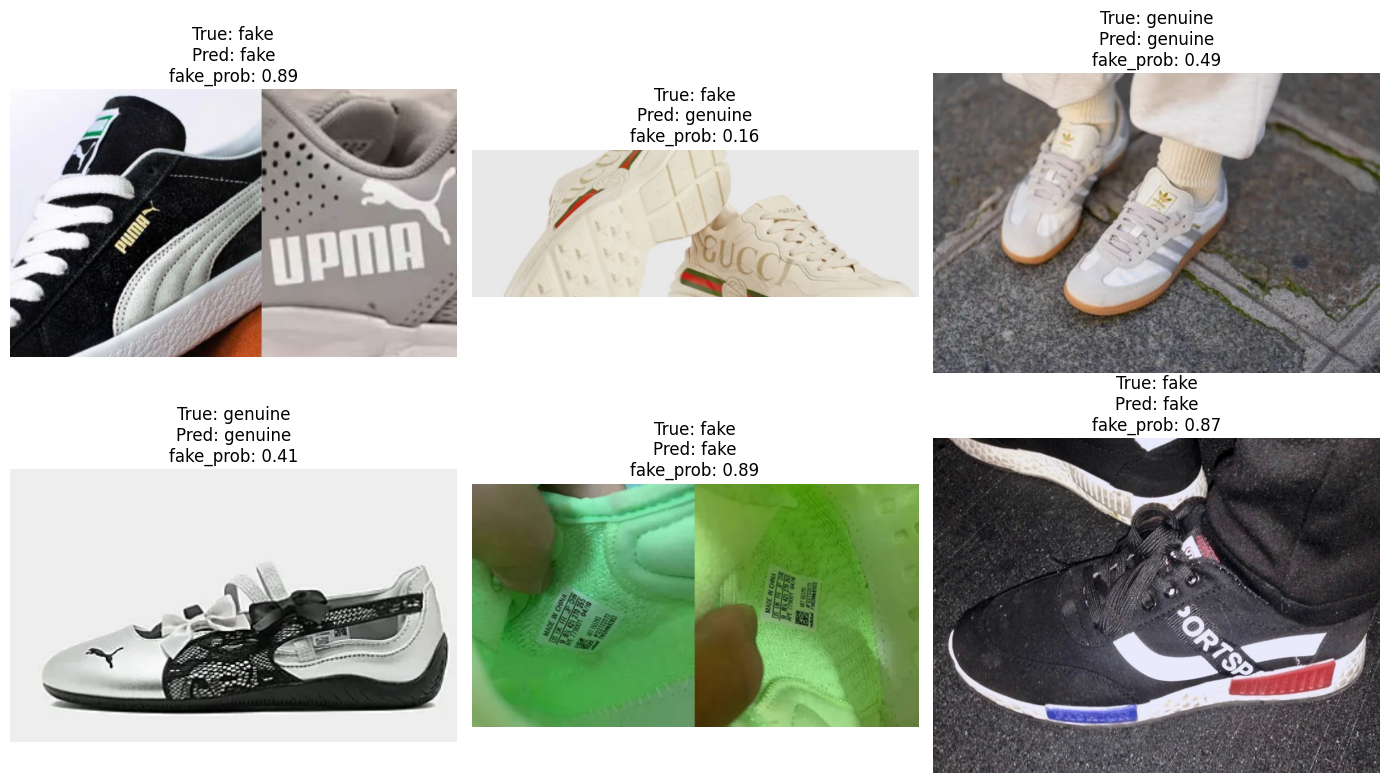

In [27]:
# 27. EXAMPLES OF PREDICTIONS

sample_batch = random.sample(test_samples, min(6, len(test_samples)))

plt.figure(figsize=(14, 8))

for i, (img_path, true_label) in enumerate(sample_batch):
    result = predict_image_tta(model, img_path, threshold=best_threshold, device=device)

    plt.subplot(2, 3, i + 1)
    plt.imshow(result["image"])
    plt.title(
        f"True: {true_label}\n"
        f"Pred: {result['label']}\n"
        f"fake_prob: {result['prob_fake']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# 28. READY-TO-USE INFERENCE FUNCTION

def predict_one_image(image_path):
    result = predict_image_tta(
        model=model,
        image_path=image_path,
        threshold=best_threshold,
        device=device
    )

    return {
        "prediction": result["label"],
        "prob_fake": round(result["prob_fake"], 4),
        "prob_genuine": round(result["prob_genuine"], 4),
        "threshold": round(best_threshold, 4)
    }

# example:
# print(predict_one_image("/content/some_image.jpg"))